In [1]:
# =========================
# 1. Imports
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from livelossplot.keras import PlotLossesCallback

In [2]:

# =========================
# 2. Load Dataset
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [3]:

# =========================
# 3. Optimize Pipeline
# =========================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)



In [4]:
# =========================
# 4. Data Augmentation
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])



In [5]:
# =========================
# 5. Transfer Learning Model
# =========================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze base model



In [6]:
# =========================
# 6. Build Model
# =========================
model = models.Sequential([
    layers.Rescaling(1./255),
    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])



In [7]:
# =========================
# 7. Compile
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [8]:
# =========================
# 8. Callbacks
# =========================
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.keras", save_best_only=True),
    CSVLogger("training_log.csv"),
    PlotLossesCallback()
]



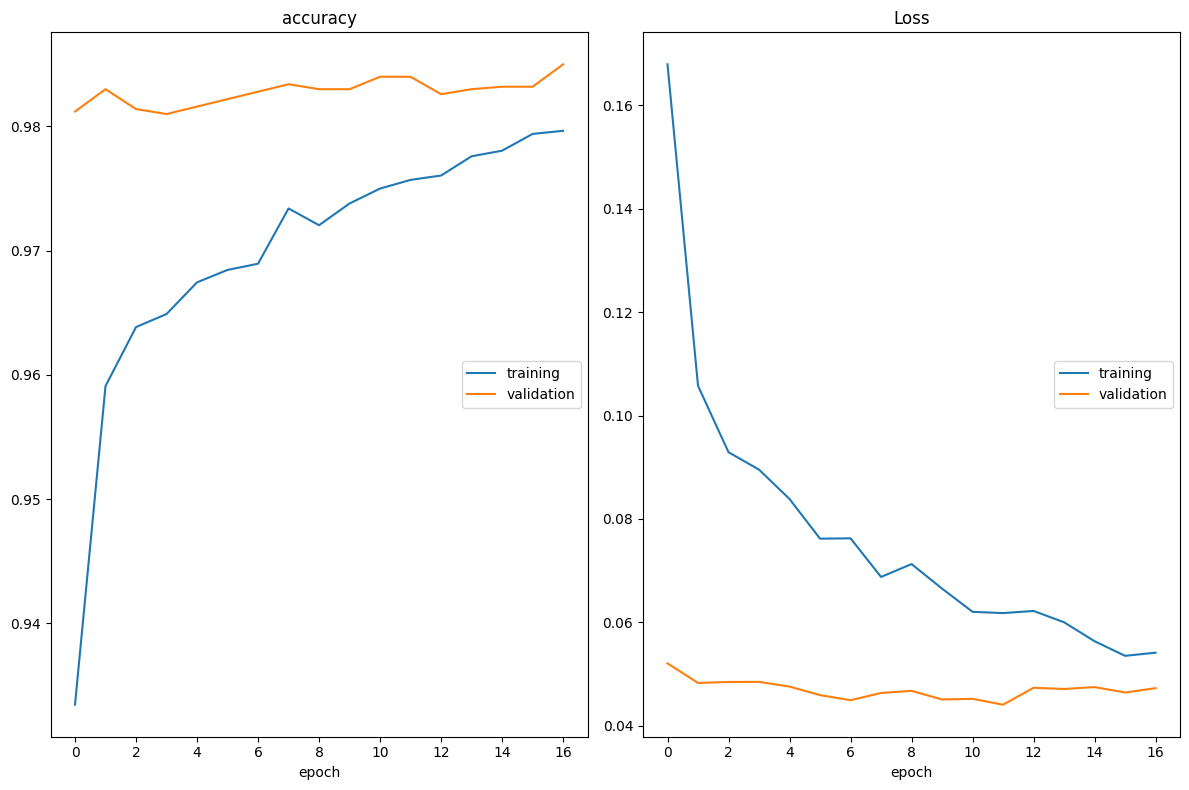

accuracy
	training         	 (min:    0.933, max:    0.980, cur:    0.980)
	validation       	 (min:    0.981, max:    0.985, cur:    0.985)
Loss
	training         	 (min:    0.054, max:    0.168, cur:    0.054)
	validation       	 (min:    0.044, max:    0.052, cur:    0.047)
625/625 [==============================] - 219s 350ms/step - loss: 0.0541 - accuracy: 0.9797 - val_loss: 0.0473 - val_accuracy: 0.9850


In [9]:
# =========================
# 9. Train
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)



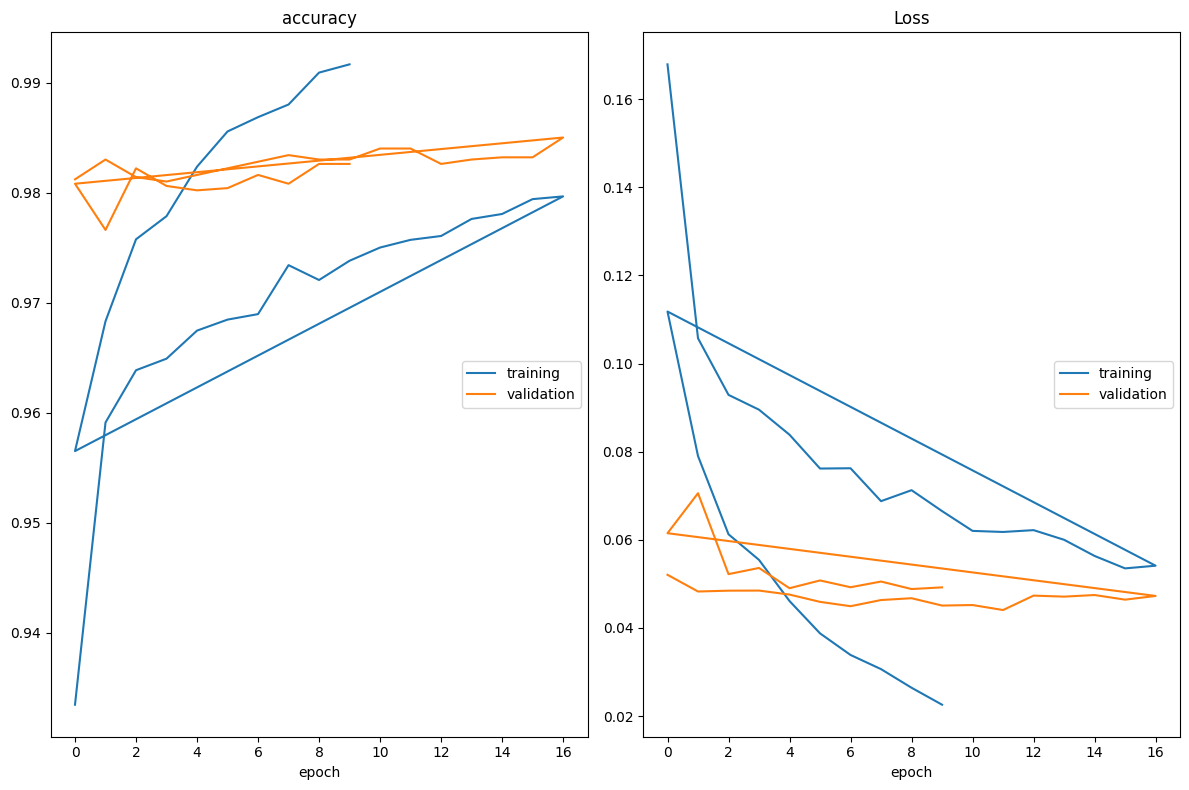

accuracy
	training         	 (min:    0.933, max:    0.992, cur:    0.992)
	validation       	 (min:    0.977, max:    0.985, cur:    0.983)
Loss
	training         	 (min:    0.023, max:    0.168, cur:    0.023)
	validation       	 (min:    0.044, max:    0.071, cur:    0.049)
625/625 [==============================] - 1013s 2s/step - loss: 0.0226 - accuracy: 0.9916 - val_loss: 0.0492 - val_accuracy: 0.9826


In [10]:
# =========================
# 10. Fine-tuning (optional but powerful)
# =========================
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


In [11]:
# =========================
# 11. Save Final Model
# =========================
model.save("final_model.keras")

In [12]:
# =========================
# 12. Model Evaluation
# =========================

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

print(classification_report(y_true, y_pred))

1/1 [==============================] - 0s 393ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      2500
         1.0       0.98      0.98      0.98      2500

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



In [13]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 4.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 kB 3.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 2.6 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 5.6 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [streamlit]18 [streamlit]-specifications]
Note: you may need to restart the kernel to use updated packages.
